In [54]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping # <-- 1. Import it
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
try:
    X_train_full = np.load("X_train.npy", allow_pickle=True)
    y_train_full = np.load("y_train.npy", allow_pickle=True)
    
    X_test = np.load("X_test.npy", allow_pickle=True)
    y_test = np.load("y_test.npy", allow_pickle=True)
    
except FileNotFoundError:
    print("Error: .npy files not found. Please run the 'create_sequences' script first.")
    exit()

print(f"X_train_full shape: {X_train_full.shape} | y_train_full shape: {y_train_full.shape}")
print(f"X_test shape: {X_test.shape}   | y_test shape: {y_test.shape}")
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, 
    y_train_full, 
    test_size=0.2,
    random_state=42, 
    stratify=y_train_full
)

Loading data from .npy files...
Original data shapes:
X_train_full shape: (12267, 2, 9) | y_train_full shape: (12267,)
X_test shape: (3067, 2, 9)   | y_test shape: (3067,)

Creating validation set...
split shapes:
X_train shape: (9813, 2, 9) | y_train shape: (9813,)
X_val shape: (2454, 2, 9)   | y_val shape: (2454,)
X_test shape: (3067, 2, 9)    | y_test shape: (3067,)


In [ ]:
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]

model = Sequential([
    Input(shape=(n_timesteps, n_features)),
    LSTM(units=50, return_sequences=True), 
    Dropout(0.2),
    LSTM(units=50, return_sequences=False), 
    Dropout(0.2),
    Dense(units=25, activation='tanh'),
    Dense(units=1, activation='sigmoid')
])

model.summary()
weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = {0: weights[0], 1: weights[1]}

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                       │ (None, 2, 50)               │          12,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_18 (Dropout)                 │ (None, 2, 50)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_19 (LSTM)                       │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,501 (130.86 KB)

 Trainable params: 33,501 (130.86 KB)

 Non-trainable params: 0 (0.00 B)


Calculating class weights from the new training set...
Class weights: {0: np.float64(0.6170145875251509), 1: np.float64(2.636485760343901)}


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

Compiling model...


In [ ]:
early_stopping_callback = EarlyStopping(
    monitor='val_loss', 
    patience=7,         
    verbose=1,          
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=200, 
    batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=class_weights_dict,
    callbacks=[early_stopping_callback], 
    verbose=1
)

Setting up EarlyStopping callback...
Training model...
Epoch 1/200
307/307 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.6092 - auc: 0.6559 - loss: 0.6541 - precision: 0.2685 - recall: 0.6153 - val_accuracy: 0.5827 - val_auc: 0.6766 - val_loss: 0.6372 - val_precision: 0.2707 - val_recall: 0.7097
Epoch 2/200
307/307 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5962 - auc: 0.6908 - loss: 0.6290 - precision: 0.2766 - recall: 0.6991 - val_accuracy: 0.6076 - val_auc: 0.6829 - val_loss: 0.6247 - val_precision: 0.2761 - val_recall: 0.6602
Epoch 3/200
307/307 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6244 - auc: 0.7050 - loss: 0.6196 - precision: 0.2905 - recall: 0.6797 - val_accuracy: 0.5827 - val_auc: 0.7054 - val_loss: 0.6549 - val_precision: 0.2808 - val_recall: 0.7699
Epoch 4/200
307/307 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6228 - auc: 0.7157 - loss: 0.6121 - precision: 0.2934 - recall: 0.7018 - val_accuracy: 0.5945 - val_auc: 0.7158 - val_loss: 0.6576 - val_precision: 

In [ ]:

results = model.evaluate(X_test, y_test, verbose=1)
print("Test Loss, Test Accuracy, Test AUC, Test Precision, Test Recall:")
print(results)


Evaluating model on the *pristine* test data...
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7868 - auc: 0.8693 - loss: 0.4279 - precision: 0.4622 - recall: 0.7676
Test Loss, Test Accuracy, Test AUC, Test Precision, Test Recall:
[0.4278865456581116, 0.7867622971534729, 0.8692658543586731, 0.4621761739253998, 0.7676420211791992]


Plotting training history...
Saved training history plot to 'model_training_history_tanh.png'


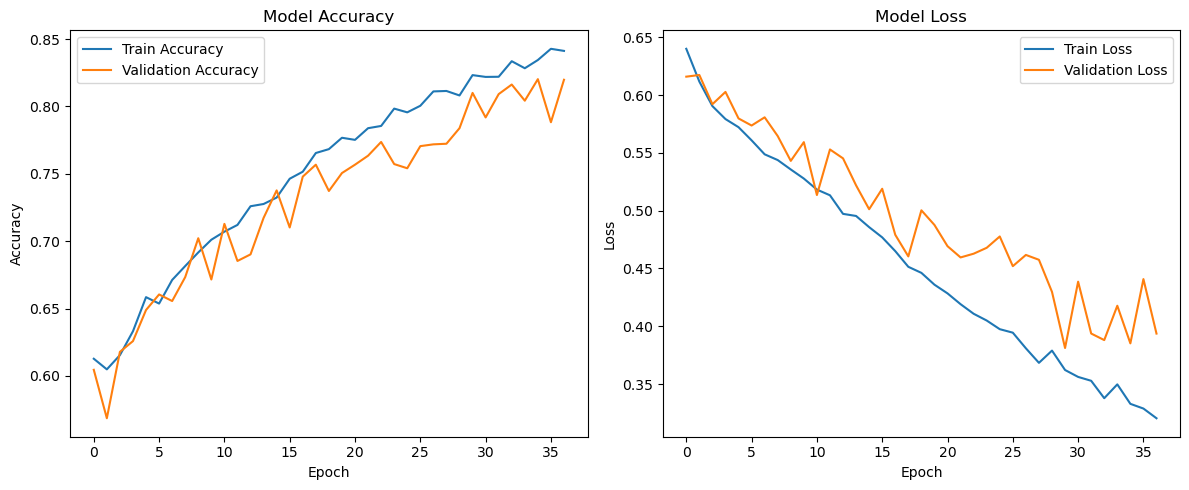

In [ ]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig("model_training_history_tanh.png")